In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Basic Dataset Loading and Information**

In [4]:
df = pd.read_csv('breast_cancer.csv')

In [5]:
df.sample(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
231,88199202,B,11.320,27.08,71.76,395.7,0.06883,0.03813,0.016330,0.003125,...,33.75,79.82,452.3,0.09203,0.14320,0.108900,0.02083,0.2849,0.07087,NaN
431,907915,B,12.400,17.68,81.47,467.8,0.10540,0.13160,0.077410,0.027990,...,22.91,89.61,515.8,0.14500,0.26290,0.240300,0.07370,0.2556,0.09359,NaN
543,922296,B,13.210,28.06,84.88,538.4,0.08671,0.06877,0.029870,0.032750,...,37.17,92.48,629.6,0.10720,0.13810,0.106200,0.07958,0.2473,0.06443,NaN
63,859196,B,9.173,13.86,59.20,260.9,0.07721,0.08751,0.059880,0.021800,...,19.23,65.59,310.1,0.09836,0.16780,0.139700,0.05087,0.3282,0.08490,NaN
333,897137,B,11.250,14.78,71.38,390.0,0.08306,0.04458,0.000974,0.002941,...,22.06,82.08,492.7,0.11660,0.09794,0.005518,0.01667,0.2815,0.07418,NaN
276,8911230,B,11.330,14.16,71.79,396.6,0.09379,0.03872,0.001487,0.003333,...,18.99,77.37,458.0,0.12590,0.07348,0.004955,0.01111,0.2758,0.06386,NaN
248,88466802,B,10.650,25.22,68.01,347.0,0.09657,0.07234,0.023790,0.016150,...,35.19,77.98,455.7,0.14990,0.13980,0.112500,0.06136,0.3409,0.08147,NaN
326,89524,B,14.110,12.88,90.03,616.5,0.09309,0.05306,0.017650,0.027330,...,18.00,98.40,749.9,0.12810,0.11090,0.053070,0.05890,0.2100,0.07083,NaN
409,905501,B,12.270,17.92,78.41,466.1,0.08685,0.06526,0.032110,0.026530,...,28.88,89.00,610.2,0.12400,0.17950,0.137700,0.09532,0.3455,0.06896,NaN
292,891670,B,12.950,16.02,83.14,513.7,0.10050,0.07943,0.061550,0.033700,...,19.93,88.81,585.4,0.14830,0.20680,0.224100,0.10560,0.3380,0.09584,NaN


In [6]:
df.shape

(569, 33)

In [7]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

**Data Cleaning**

In [9]:
df = df.drop(['id', 'Unnamed: 32'], axis = 1)

In [10]:
df.shape

(569, 31)

**Data Preprocessing**

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [12]:
df['diagnosis'] = le.fit_transform(df['diagnosis'])

In [13]:
df['diagnosis'].value_counts()

,count
diagnosis,
0,357
1,212


In [14]:
feature_cols = ['radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst']

target_col = ['diagnosis']

X = df[feature_cols]
y = df[target_col]

In [15]:
print(X.shape)
print(y.shape)

(569, 30)
(569, 1)


**Train Test Split**

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [18]:
for i in [X_train, X_test, y_train, y_test]:
  print(i.shape)

(455, 30)
(114, 30)
(455, 1)
(114, 1)


**Pipeline, Scaling and Model Training**

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [20]:
pipeline1 = Pipeline([
    ("Scaler", StandardScaler()),
    ("Model", LogisticRegression())
])

pipeline2 = Pipeline([
    ("Scaler", StandardScaler()),
    ("Model", DecisionTreeClassifier())
])

pipeline3 = Pipeline([
    ("Scaler", StandardScaler()),
    ("Model", RandomForestClassifier())
])

pipeline4 = Pipeline([
    ("Scaler", StandardScaler()),
    ("Model", XGBClassifier())
])

for i in [pipeline1, pipeline2, pipeline3, pipeline4]:
  i.fit(X_train, y_train)

y_pred1 = pipeline1.predict(X_test)
y_pred2 = pipeline2.predict(X_test)
y_pred3 = pipeline3.predict(X_test)
y_pred4 = pipeline4.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


**Model Accuracy Comparision**

In [21]:
from sklearn.metrics import accuracy_score

In [22]:
acc1 = accuracy_score(y_test, y_pred1)
acc2 = accuracy_score(y_test, y_pred2)
acc3 = accuracy_score(y_test, y_pred3)
acc4 = accuracy_score(y_test, y_pred4)

In [23]:
for i, j in zip(['Logistic Regression : ', 'Decision Tree : ', 'Random Forest : ', 'XGBoost : '], [acc1, acc2, acc3, acc4]):
  print(i,j)

Logistic Regression :  0.9736842105263158
Decision Tree :  0.9473684210526315
Random Forest :  0.9649122807017544
XGBoost :  0.956140350877193


In this case, Logistic Regression is yielding highest accuracy

**Metrics Calculation**

In [24]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [25]:
cm = confusion_matrix(y_test, y_pred1)
print(cm)

[[70  1]
 [ 2 41]]


True Negatives (TN) = 70

False Positives (FP) = 1

False Negatives (FN) = 2

True Positives (TP) = 41

In [26]:
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



**Feature Importance Analysis**

In [29]:
model_lr = pipeline1.named_steps['Model']

In [35]:
coefficients = model_lr.coef_[0]
feature_importance = pd.DataFrame({"features": X.columns, "coefficients": coefficients})

In [36]:
feature_importance["importance"] = feature_importance["coefficients"].abs()
feature_importance = feature_importance.sort_values(by = "importance", ascending = False)

print(feature_importance.head(10))

                features  coefficients  importance
21         texture_worst      1.350606    1.350606
10             radius_se      1.268178    1.268178
28        symmetry_worst      1.208200    1.208200
7    concave points_mean      1.119804    1.119804
26       concavity_worst      0.943053    0.943053
13               area_se      0.907186    0.907186
20          radius_worst      0.879840    0.879840
23            area_worst      0.841846    0.841846
6         concavity_mean      0.801458    0.801458
27  concave points_worst      0.778217    0.778217


<Axes: xlabel='features', ylabel='importance'>

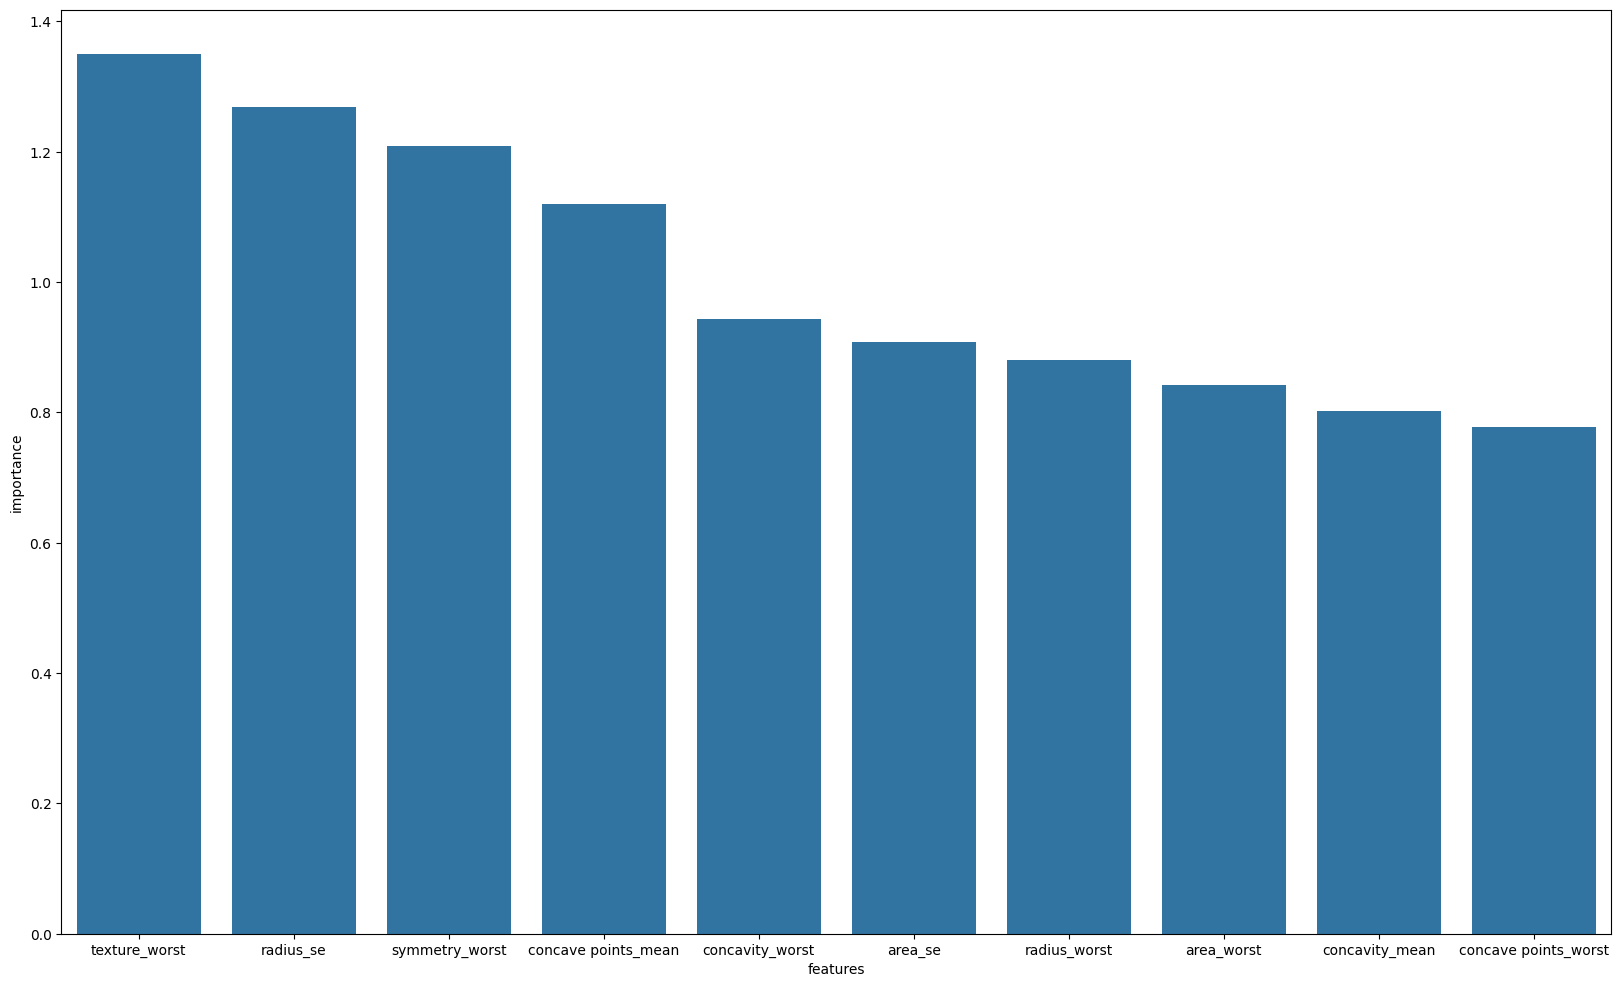

In [43]:
plt.figure(figsize=(20,12))
sns.barplot(x = feature_importance['features'][0:10], y = feature_importance['importance'][0:10])

In Logistic Regression, more absolute value of coefficient of a feature signifies that the feature has more impact on the classification as we can see above, texture_worst has the highest impact on the classification due to max coefficient.

<Axes: >

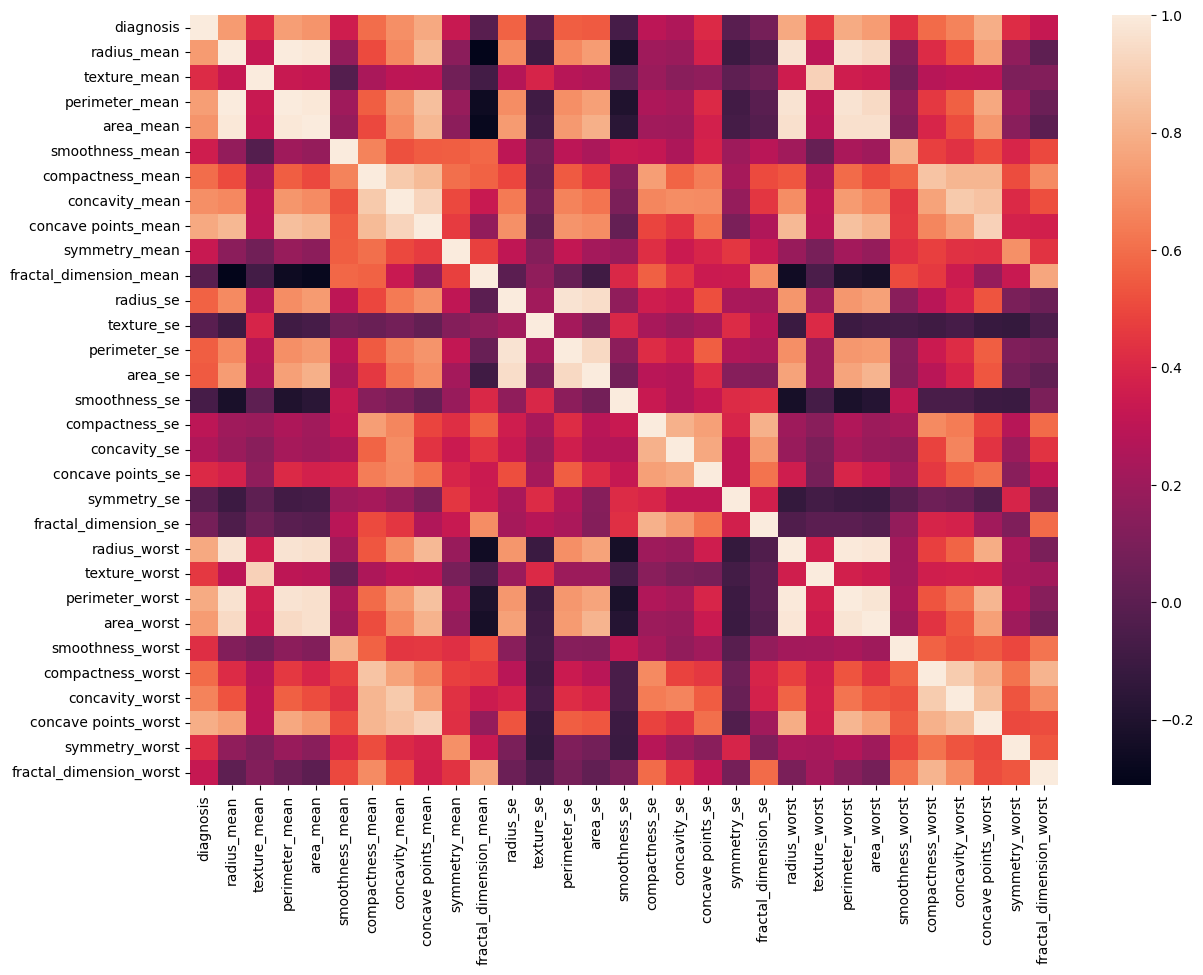

In [50]:
plt.figure(figsize=(14,10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix)

Correlation analysis was performed to understand relationships between features. Strong correlations were observed between radius, perimeter, and area features, which is expected due to their geometric relationships.

**Exporting the model**

In [44]:
import joblib

In [45]:
joblib.dump(pipeline1, "breast_cancer_model.pkl")

['breast_cancer_model.pkl']